In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


# --- CONFIGURE YOUR ROOT FOLDERS HERE ---
all_outputs_dirs = [
    "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs",
    "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs",
]
all_geneval_results_dirs = [
    "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_results_best",
    "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_results_best",
]


bon =  {
    "outputs": all_outputs_dirs[0],
    "geneval_results": all_geneval_results_dirs[0],
    "filters": {
        "use_smc": False,
    },
    "label": "Best-of-N",
}
fk_steering_lmbda_50_phi_4 = {
    "outputs": all_outputs_dirs[0],
    "geneval_results": all_geneval_results_dirs[0],
    "filters": {
        "use_smc": True,
        "lmbda": 50.0,
        "num_x0_samples": 4,
        "use_fkd_log_impl": True,
    },
    "label": r"Fk-Steering ($\lambda = 50.0, \phi = 4$)",
}
fk_steering_lmbda_50_phi_1 = {
    "outputs": all_outputs_dirs[0],
    "geneval_results": all_geneval_results_dirs[0],
    "filters": {
        "use_smc": True,
        "lmbda": 50.0,
        "num_x0_samples": 1,
        "use_fkd_log_impl": True,
    },
    "label": r"Fk-Steering ($\lambda = 50.0, \phi = 1$)",
}
smc_grad_kl_0_02_phi_4 = {
    "outputs": all_outputs_dirs[1],
    "geneval_results": all_geneval_results_dirs[1],
    "filters": {
        "proposal_type": "locally_optimal",
        "kl_weight": 0.02,
        "phi": 4,
    },
    "label": r"SMC-Grad ($\alpha = 0.02, \phi = 4$)",
}
bon_ft = {
    "outputs": all_outputs_dirs[1],
    "geneval_results": all_geneval_results_dirs[1],
    "filters": {
        "proposal_type": "without_SMC",
        "lora_ckpt_uuid": "a1e906e1-16a9-44a3-abe8-6dd2c17e12a2"
    },
    "label": "Best-of-N (FT)",
}
smc_ft_kl_0_02_phi_4 = {
    "outputs": all_outputs_dirs[1],
    "geneval_results": all_geneval_results_dirs[1],
    "filters": {
        "proposal_type": "reverse",
        "lora_ckpt_uuid": "a1e906e1-16a9-44a3-abe8-6dd2c17e12a2",
        "kl_weight": 0.02,
        "phi": 4,
    },
    "label": r"SMC (FT) ($\alpha = 0.02, \phi = 4$)",
}
smc_ft_kl_0_02_phi_1 = {
    "outputs": all_outputs_dirs[1],
    "geneval_results": all_geneval_results_dirs[1],
    "filters": {
        "proposal_type": "reverse",
        "lora_ckpt_uuid": "a1e906e1-16a9-44a3-abe8-6dd2c17e12a2",
        "kl_weight": 0.02,
        "phi": 1,
    },
    "label": r"SMC (FT) ($\alpha = 0.02, \phi = 1$)",
}

all_configs = [bon, fk_steering_lmbda_50_phi_4, fk_steering_lmbda_50_phi_1, smc_grad_kl_0_02_phi_4, bon_ft, smc_ft_kl_0_02_phi_4, smc_ft_kl_0_02_phi_1] 
# all_configs = [bon, smc_grad_kl_0_02_phi_4, bon_ft, smc_ft_kl_0_02_phi_4, smc_ft_kl_0_02_phi_1] 

plot_data = defaultdict(dict)

for output_dir in all_outputs_dirs:
    for run_dir in os.listdir(output_dir):
        run_dir_path = os.path.join(output_dir, run_dir)
        if not os.path.isdir(run_dir_path):
            continue
        # Skip dir if final_metrics.json does not exist
        if not os.path.exists(os.path.join(run_dir_path, "final_metrics.json")):
            continue
        
        # load args.json
        with open(os.path.join(run_dir_path, "args.json"), "r") as f:
            args = json.load(f)
        
        matched_configs = []
        # check if any config matches
        for config in all_configs:
            if config["outputs"] == output_dir:
                is_match = True
                for key, value in config["filters"].items():
                    if args.get(key, None) != value:
                        is_match = False
                        break
                if is_match:
                    matched_configs.append(config)
        
        if len(matched_configs) == 0:
            continue
        assert len(matched_configs) == 1, "More than one config matched"
        
        config = matched_configs[0]
        
        num_particles = args["num_particles"]
        assert plot_data[config["label"]].get(num_particles, None) is None, "Duplicate num_particles"
        plot_data[config["label"]][num_particles] = {}
        
        # Calculate imagereward and hps scores
        image_reward_scores, hps_scores = [], []
        for prompt_dir in os.listdir(run_dir_path):
            prompt_dir_path = os.path.join(run_dir_path, prompt_dir)
            if not os.path.isdir(prompt_dir_path):
                continue
            # load results.json
            with open(os.path.join(prompt_dir_path, "results.json"), "r") as f:
                results = json.load(f)
                # image_reward_scores.append(results["ImageReward"]["max"])
                # hps_scores.append(results["HumanPreference"]["max"])
                best_img_idx = np.argmax(results["ImageReward"]["result"])
                image_reward_scores.append(results["ImageReward"]["result"][best_img_idx])
                hps_scores.append(results["HumanPreference"]["result"][best_img_idx])
            plot_data[config["label"]][num_particles]["imagereward"] = np.mean(image_reward_scores)
            plot_data[config["label"]][num_particles]["hps"] = np.mean(hps_scores)
            
        # Calculate geneval scores
        geneval_results_dir = os.path.join(config["geneval_results"], run_dir)
        # load summary.json
        # if not os.path.exists(os.path.join(geneval_results_dir, "summary.json")):
        #     continue
        with open(os.path.join(geneval_results_dir, "summary.json"), "r") as f:
            summary = json.load(f)
            plot_data[config["label"]][num_particles]["geneval"] = summary["overall_score"]

In [2]:
# Write to csv sorted by num_particles 
import csv
with open("all_scores.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["label", "num_particles", "imagereward", "hps", "geneval"])
    for label, data in plot_data.items():
        for num_particles, scores in sorted(data.items()):
            writer.writerow([label, num_particles, scores.get("imagereward", None), scores.get("hps", None), scores.get("geneval", None)])

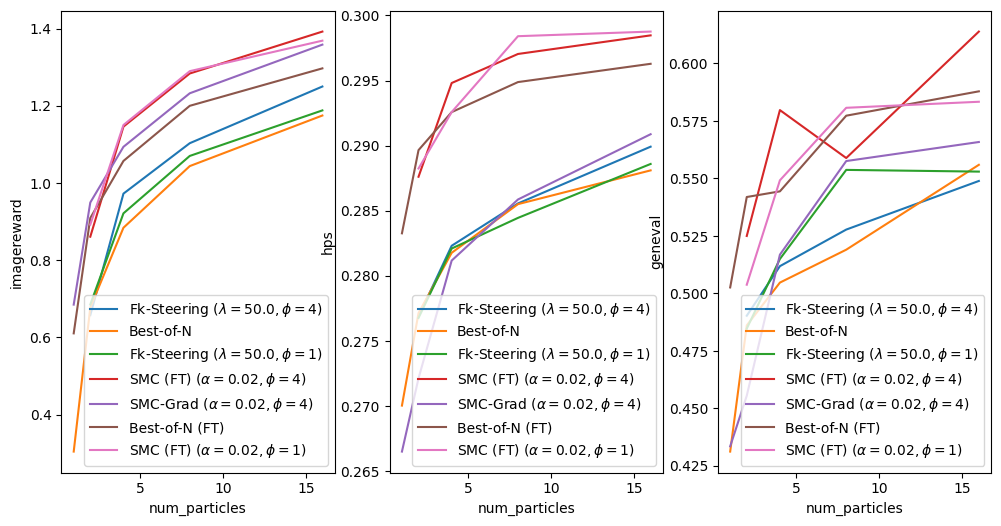

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
for i, metric in enumerate(["imagereward", "hps", "geneval"]):
    for label, data in plot_data.items():
        x = sorted(data.keys())
        y = [data[num_particles][metric] for num_particles in x]
        ax[i].plot(x, y, label=label)
        ax[i].set_xlabel("num_particles")
        ax[i].set_ylabel(metric)
        # ax[i].set_title(metric)
        ax[i].legend()
plt.show()

ValueError: Invalid RGBA argument: None

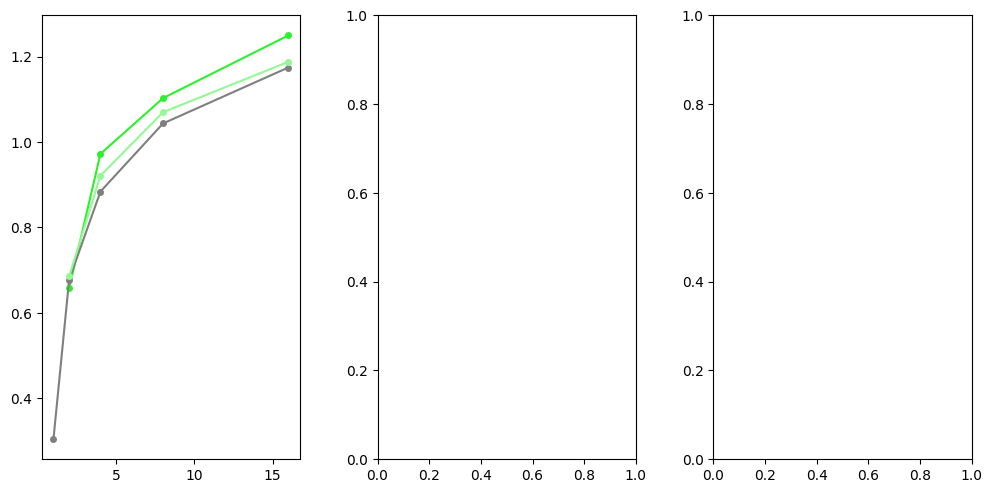

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex

# helper: map a label to one of the 4 categories
def category_of(label):
    if label == "Best-of-N":
        return "best"
    if label == "Best-of-N (FT)":
        return "best_ft"
    if "Fk-Steering" in label:
        return "fk"
    if "SMC-FALOP" in label:
        return "smc"
    return "other"

# helper: produce a variant (tint) of a base color by mixing with white
def tint(hex_color, t):
    r, g, b = to_rgb(hex_color)
    r = r + (1 - r) * t
    g = g + (1 - g) * t
    b = b + (1 - b) * t
    return to_hex((r, g, b))

# base colors for categories
base_colors = {
    "best": "#7f7f7f",
    "best_ft": "#ff7f0e",
    "fk": "#2cf02c",
    "smc": "#d62728",
    # "other": "#7f7f7f",
}
metric_labels = {
    "imagereward": "ImageReward Score",
    "hps": "HumanPreference Score",
    "geneval": "GenEVAL Score",
}


# build groups (preserve plot_data order)
groups = {}
for label in plot_data.keys():
    cat = category_of(label)
    groups.setdefault(cat, []).append(label)

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
fig.subplots_adjust(wspace=0.3, top=0.85)  # room for top legend

lines = {}  # collect one handle per label for the single legend
for i, metric in enumerate(["imagereward", "hps", "geneval"]):
    for label, data in plot_data.items():
        x = sorted(data.keys())
        y = [data[num_particles][metric] for num_particles in x]

        cat = category_of(label)
        same_group = groups.get(cat, [])
        idx = same_group.index(label)
        total = len(same_group)

        t = 0 if total == 1 else (idx / max(1, total - 1)) * 0.5
        color = tint(base_colors.get(cat), t)

        line, = ax[i].plot(x, y, label=label, color=color, marker="o", markersize=4)
        if label not in lines:
            lines[label] = line

    ax[i].set_xlabel("Number of particles")
    ax[i].set_xticks([1, 2, 4, 8, 16])
    # ax[i].set_xscale('log')
    ax[i].set_ylabel(metric_labels[metric])

# single legend at top
handles = list(lines.values())
labels = list(lines.keys())
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.98))

plt.show()